# Motor Third-Party Liability - Exploratory Data Analysis (EDA)

This notebook explores our analytical pricing dataset stored in DuckDB (`mart_pricing`) before modeling claim frequency and severity.

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load Data from DuckDB

In [2]:
# Connect to DuckDB relative to notebooks directory
db_path = os.path.join('..', 'data', 'insurance.db')
conn = duckdb.connect(db_path)

# Read data into Pandas DataFrame
df = conn.execute("SELECT * FROM mart_pricing").fetchdf()
conn.close()

print(f"Loaded {len(df)} rows and {df.shape[1]} columns.")
df.head()

Loaded 678013 rows and 17 columns.


,policy_id,exposure,area_code,vehicle_power,vehicle_age,driver_age,bonus_malus,vehicle_brand,fuel_type,population_density,region_code,region_name,region_population,claim_count,total_claim_amount,has_claim,avg_claim_amount
0,2280617,0.84,D,4,6,52,50,B2,Diesel,609,R93,Provence-Alpes-Cote-d-Azur (PACA),4984058,1,1500.00,True,1500.00
1,2280631,0.56,D,10,0,47,68,B6,Regular,769,R82,Rhone-Alpes,6384816,1,602.24,True,602.24
2,2280664,0.88,E,7,3,35,57,B1,Diesel,9307,R82,Rhone-Alpes,6384816,1,10000.00,True,10000.00
3,2280678,0.69,E,7,4,29,68,B10,Regular,3317,R93,Provence-Alpes-Cote-d-Azur (PACA),4984058,1,589.51,True,589.51
4,2280739,0.41,D,5,4,41,50,B3,Diesel,1326,R93,Provence-Alpes-Cote-d-Azur (PACA),4984058,1,748.22,True,748.22


## 2. Dataset Overview

In [3]:
print("DataFrame Info:")
df.info()
print("\nSummary Statistics:")
df.describe()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   policy_id           678013 non-null  int64  
 1   exposure            678013 non-null  float64
 2   area_code           678013 non-null  object 
 3   vehicle_power       678013 non-null  int32  
 4   vehicle_age         678013 non-null  int32  
 5   driver_age          678013 non-null  int32  
 6   bonus_malus         678013 non-null  int32  
 7   vehicle_brand       678013 non-null  object 
 8   fuel_type           678013 non-null  object 
 9   population_density  678013 non-null  int32  
 10  region_code         678013 non-null  object 
 11  region_name         678013 non-null  object 
 12  region_population   678013 non-null  int64  
 13  claim_count         678013 non-null  int32  
 14  total_claim_amount  678013 non-null  float64
 15  has_claim         

,policy_id,exposure,vehicle_power,vehicle_age,driver_age,bonus_malus,population_density,region_population,claim_count,total_claim_amount,avg_claim_amount
count,6.780130e+05,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,6.780130e+05,678013.000000,6.780130e+05,6.780130e+05
mean,2.621857e+06,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405,4.409840e+06,0.053247,8.835998e+01,8.172379e+01
std,1.641783e+06,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564,2.918048e+06,0.240117,5.822454e+03,5.576565e+03
min,1.000000e+00,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000,3.148670e+05,0.000000,0.000000e+00,0.000000e+00
25%,1.157951e+06,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000,2.619613e+06,0.000000,0.000000e+00,0.000000e+00
50%,2.272152e+06,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000,3.301802e+06,0.000000,0.000000e+00,0.000000e+00
75%,4.046274e+06,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000,4.984058e+06,0.000000,0.000000e+00,0.000000e+00
max,6.114330e+06,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000,1.193871e+07,16.000000,4.075401e+06,4.075401e+06


## 3. Claim Frequency Distribution

Insurance portfolios are highly skewed — most policies have 0 claims.

Claim count breakdown:
claim_count
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64


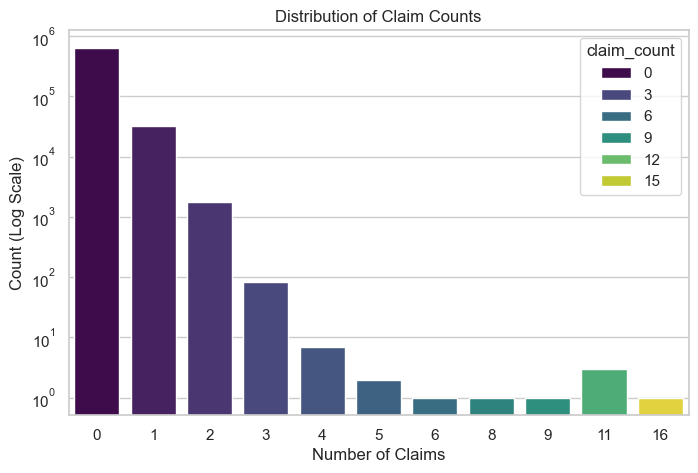

In [5]:
claim_counts = df['claim_count'].value_counts().sort_index()
print("Claim count breakdown:")
print(claim_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='claim_count', hue='claim_count', palette='viridis')
plt.title('Distribution of Claim Counts')
plt.yscale('log') # Log scale helps visualize non-zero claim counts since 0 dominates
plt.ylabel('Count (Log Scale)')
plt.xlabel('Number of Claims')
plt.show()

## 4. Claim Severity Tail Behavior

For policies that had claims, what did the average claim amount look like? Reinsurance severity distributions are typically heavy-tailed.

Number of policies with claims: 34060
count    3.406000e+04
mean     1.626829e+03
std      2.483053e+04
min      0.000000e+00
25%      0.000000e+00
50%      1.018020e+03
75%      1.204000e+03
max      4.075401e+06
Name: avg_claim_amount, dtype: float64


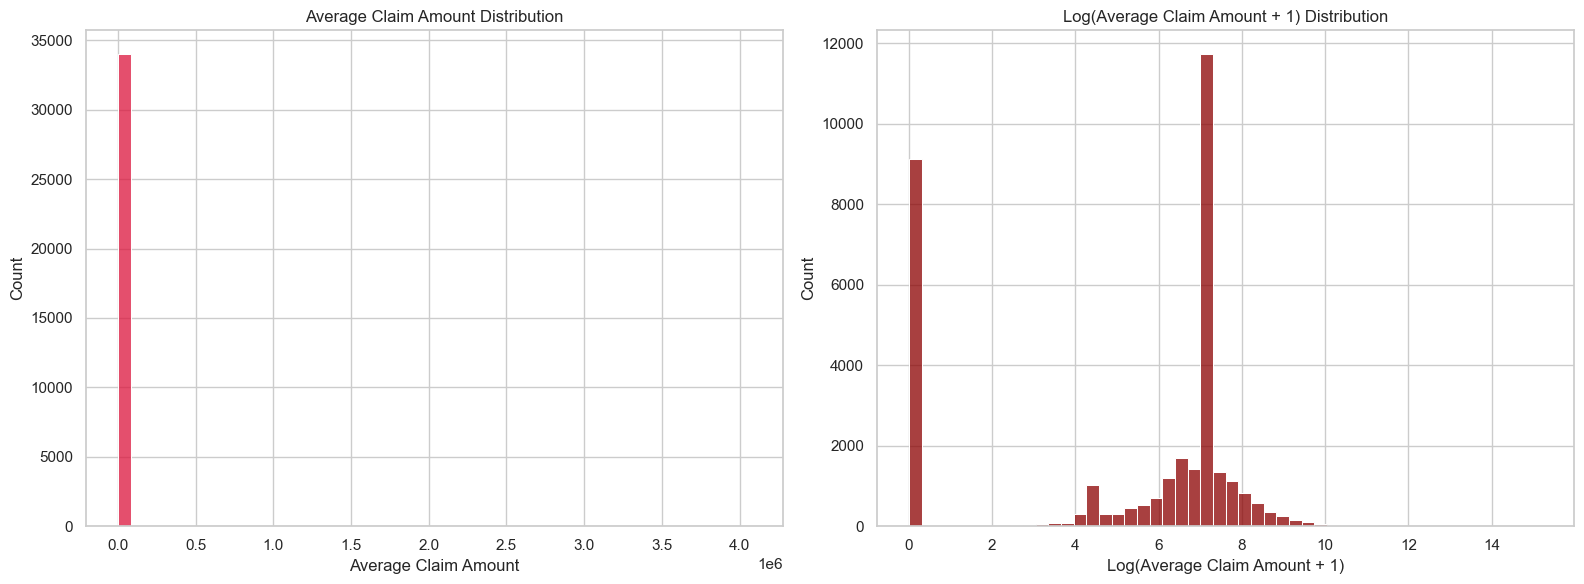

In [6]:
claimed_policies = df[df['has_claim'] == True]
print(f"Number of policies with claims: {len(claimed_policies)}")
print(claimed_policies['avg_claim_amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot raw average claim amount
sns.histplot(data=claimed_policies, x='avg_claim_amount', bins=50, ax=axes[0], color='crimson')
axes[0].set_title('Average Claim Amount Distribution')
axes[0].set_xlabel('Average Claim Amount')

# Plot log-scaled average claim amount
import numpy as np
sns.histplot(x=np.log1p(claimed_policies['avg_claim_amount']), bins=50, ax=axes[1], color='darkred')
axes[1].set_title('Log(Average Claim Amount + 1) Distribution')
axes[1].set_xlabel('Log(Average Claim Amount + 1)')

plt.tight_layout()
plt.show()

## 5. Exposure Analysis by Region

Let's see how exposure is concentrated across different regions and look at claim frequency.

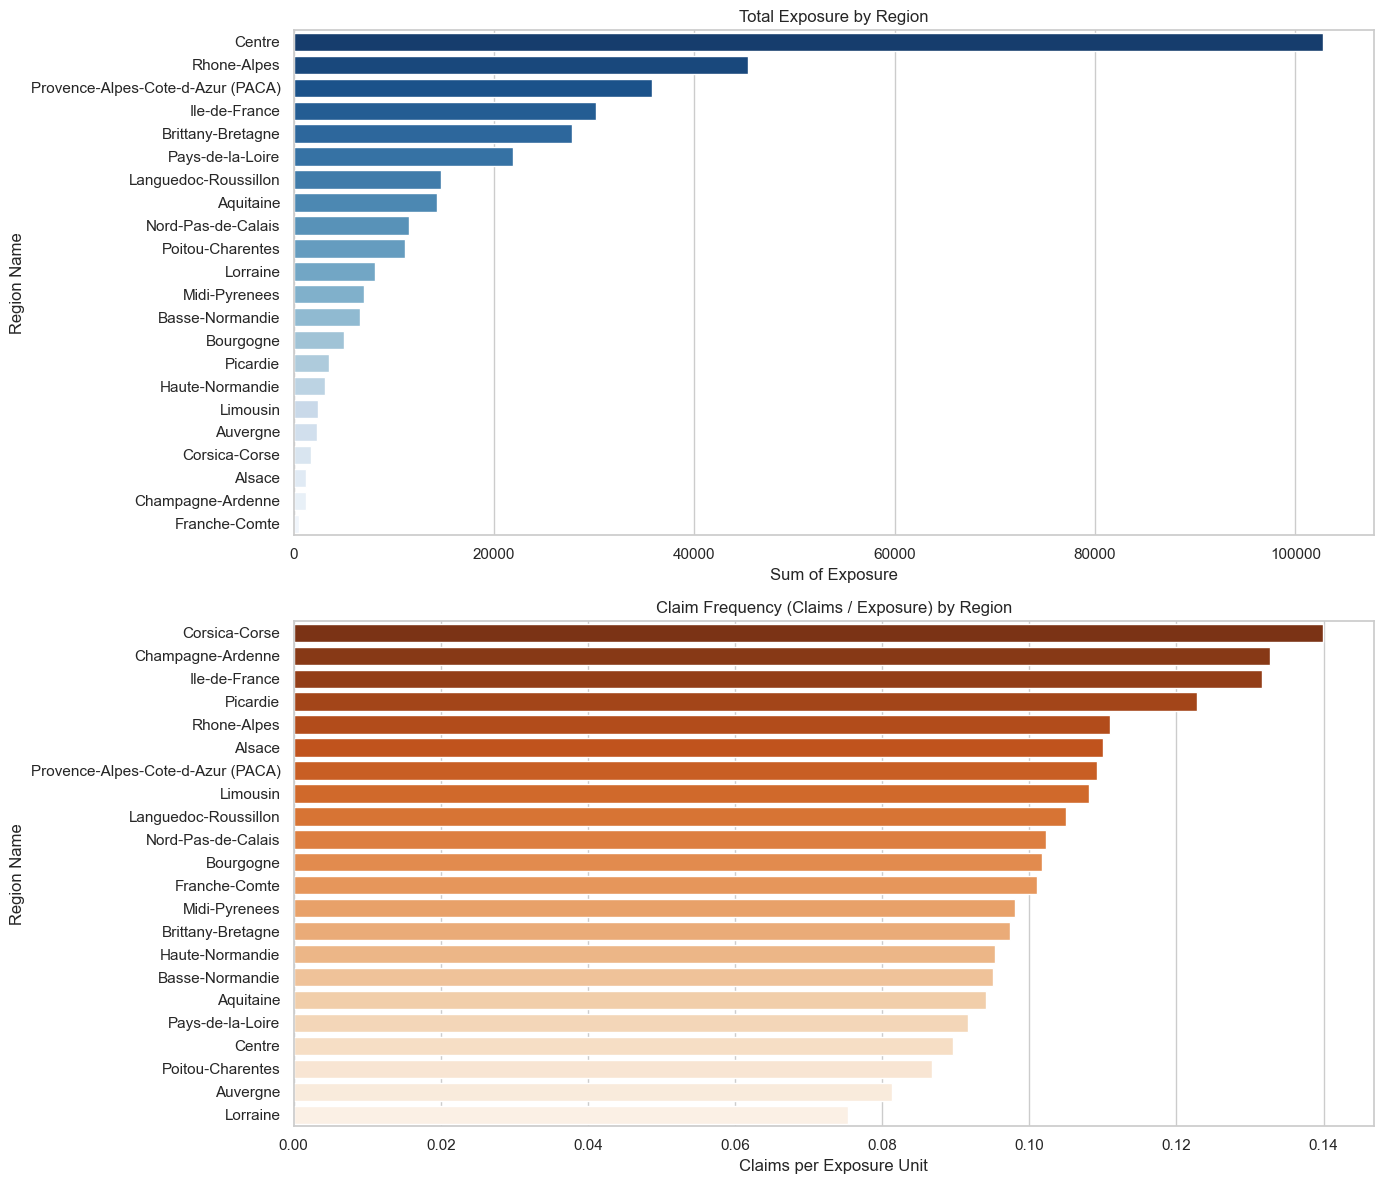

In [8]:
region_exposure = df.groupby('region_name').agg(
    total_exposure=('exposure', 'sum'),
    total_claims=('claim_count', 'sum')
).reset_index()
region_exposure['claims_per_exposure'] = region_exposure['total_claims'] / region_exposure['total_exposure']
region_exposure = region_exposure.sort_values(by='total_exposure', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.barplot(data=region_exposure, x='total_exposure', y='region_name', ax=axes[0], hue='region_name', palette='Blues_r')
axes[0].set_title('Total Exposure by Region')
axes[0].set_xlabel('Sum of Exposure')
axes[0].set_ylabel('Region Name')

sns.barplot(data=region_exposure.sort_values(by='claims_per_exposure', ascending=False), x='claims_per_exposure', y='region_name', ax=axes[1], hue='region_name', palette='Oranges_r')
axes[1].set_title('Claim Frequency (Claims / Exposure) by Region')
axes[1].set_xlabel('Claims per Exposure Unit')
axes[1].set_ylabel('Region Name')

plt.tight_layout()
plt.show()

## 6. Bonus/Malus Distribution

Bonus/Malus is a key rating factor (French system: 50 is best, 100 is neutral, >100 is bad).

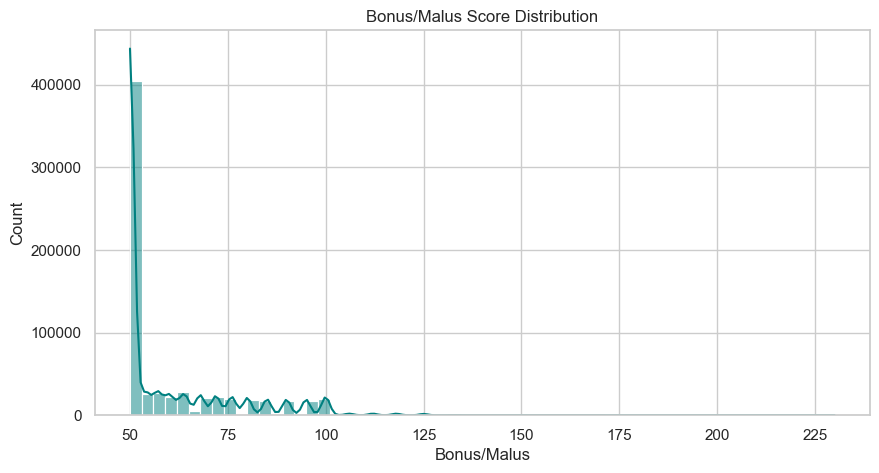

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='bonus_malus', bins=60, kde=True, color='teal')
plt.title('Bonus/Malus Score Distribution')
plt.xlabel('Bonus/Malus')
plt.show()

## 7. Correlation Analysis

Understanding relationships between numerical risk features.

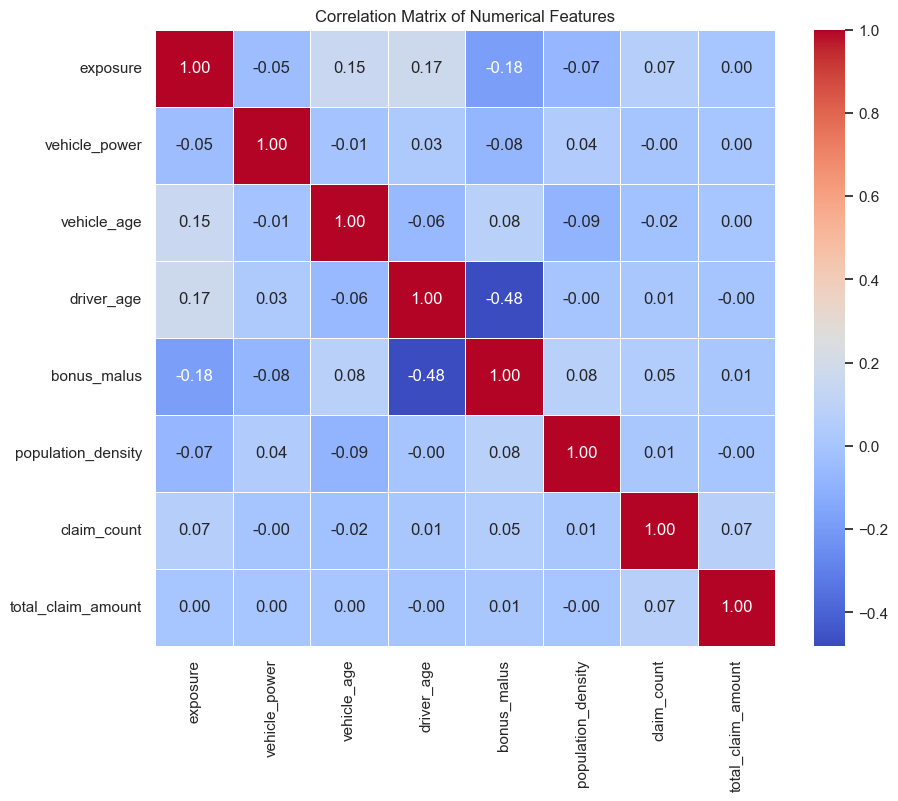

In [10]:
numerical_cols = ['exposure', 'vehicle_power', 'vehicle_age', 'driver_age', 'bonus_malus', 'population_density', 'claim_count', 'total_claim_amount']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()